# H3 — Structural (Morgan fingerprint) similarity networks

## Purpose
This notebook turns the per-pair structural similarity scores computed in [`structural_sim_notebook.ipynb`](./structural_sim_notebook.ipynb) into weighted, undirected `networkx` graphs suitable for node2vec embedding.

Structural similarity is a **bottom-up, chemistry-only** view of drug relatedness -- Tanimoto similarity between Morgan (ECFP-style) fingerprints (radius 2, 2048 bits) computed purely from each drug's 2D molecular graph, independent of biology or clinical use. See `structural_sim_notebook.ipynb` for the exact fingerprint generation code.

We build **two** graphs -- one over the curated *adverse* DDI pairs, one over the sampled *non-interacting* pairs -- so downstream models can compare embeddings learned from each pair population. We also build a **third, combined** graph (union of both populations, label-agnostic) that `node2vec_embedding.ipynb` uses to train the single canonical embedding a downstream classifier should actually use.

## Pipeline
1. Load the per-pair Tanimoto similarity scores.
2. Derive a per-drug fingerprint "on-bit count" size proxy (used by the size-leakage diagnostic) directly from each drug's SMILES.
3. Pivot each pair-list into a dense drug-by-drug similarity matrix.
4. Sparsify each dense matrix into a graph using [`src/network_builder.py`](../../src/network_builder.py) (hybrid top-k + minimum-similarity sparsification).
5. Run the network diagnostics suite (edge-weight sanity, degree distribution, DDI-topology check) on both graphs.
6. Save both graphs to GraphML under `networks/`.
7. Build and save a third, combined graph (union of both populations) for node2vec.

## Key caveat -- read before trusting the diagnostics
These parquet files only contain the **specific pairs that were sampled** for the adverse/non-interacting datasets, not the full N-choose-2 universe of DrugBank pairs. When we pivot into a dense matrix (Section 3), every unsampled pair is filled with `0.0` -- this conflates "never measured" with "measured and dissimilar". That's an acceptable approximation for this project's two curated pair populations, but it means the diagnostics below describe how well structural similarity separates *these specific* adverse vs. non-interacting samples, not a fully general drug-drug similarity space.

## Glossary (Reference for Definitions)

This notebook uses a lot of specialized vocabulary. Here's what everything means, roughly in the order it first comes up:

- **Graph / node / edge:** A *graph* here is just drugs (the *nodes*, i.e. the dots) connected by lines (the *edges*) whenever two drugs are "similar enough." Each edge also carries a *weight* -- a number saying *how* similar, not just *whether* they're similar.
- **Undirected:** The connection between two drugs goes both ways equally -- there's no "sender" or "receiver," just "these two are related."
- **node2vec:** A machine-learning technique (used later in this project, not in this notebook) that reads a graph and converts each node into a list of numbers (an "embedding") summarizing its neighborhood, which can then be fed into a predictive model. This notebook's whole job is to build a graph that is *good input* for that later step.
- **DrugBank ID:** The unique code (like `DB00001`) that the [DrugBank](https://go.drugbank.com/) database assigns to each drug.
- **SMILES:** A compact text notation for writing a molecule's structure as a string of characters (e.g. `CCO` for ethanol) -- a shorthand chemical formula that also encodes how the atoms are connected.
- **Morgan fingerprint (a.k.a. ECFP):** A way of converting a molecule's structure into a long list of 0s and 1s ("bits"). Each "on" bit (1) means "this molecule contains a certain small structural pattern somewhere." Similar molecules end up with many of the same bits switched on.
- **Radius:** How far out from each atom the fingerprint looks when deciding what counts as a "pattern." Radius 2 means it considers each atom's neighborhood out to 2 chemical bonds away.
- **n_bits:** How many yes/no slots the fingerprint has (2048 here). More bits give more precision (fewer different patterns get mashed into the same slot) at the cost of more computation.
- **On-bit count:** How many of those 2048 slots are switched to "yes" for a given molecule -- roughly, how structurally "busy" or complex that molecule's fingerprint is.
- **Jaccard similarity:** A simple overlap measure: (things both molecules have) ÷ (all the things either molecule has). 0 = no overlap at all, 1 = identical.
- **Tanimoto similarity:** The standard way to compare two Morgan fingerprints -- it's Jaccard similarity applied specifically to each molecule's "on" bits.
- **Sparsification:** If we connected every drug to every other drug with any nonzero similarity, the resulting graph would be enormous and mostly noise. *Sparsifying* means deliberately keeping only the strongest, most meaningful connections and throwing the rest away.
- **Dense matrix vs. pair list:** A *pair list* (what our parquet files contain) is a table of only the specific drug pairs we happened to sample -- like a list of phone calls that were actually made. A *dense matrix* is a full grid comparing every drug to every other drug -- like a mileage chart between every pair of cities, filled in even for cities that never called each other (we fill those in with 0).
- **k-nearest-neighbors ("top-k"):** For each drug, keep only its `k` most similar other drugs -- like each person keeping only their 15 closest friends instead of everyone they've ever met.
- **Hybrid sparsification:** Our chosen strategy: combine top-k ("each drug keeps its best `k` connections") with a minimum-similarity floor ("but only if the connection is actually meaningful"), so a drug with no good matches isn't forced to keep 15 near-meaningless ones just to hit the quota.
- **Spearman correlation ("rho", ρ):** A score from -1 to 1 measuring whether two things tend to rise and fall together (not necessarily in a straight line). 0 means no relationship; close to +1 or -1 means a strong relationship. We use this to check that edge weight isn't secretly just tracking fingerprint on-bit count.
- **"Size leakage":** A pitfall where a similarity score looks meaningful but is actually just reflecting how *much data* a drug has (e.g. a structurally "busy" molecule will share fragments with almost anyone), rather than genuine chemical relatedness.
- **Isolate (isolated node):** A drug left with zero connections after sparsification -- useless for node2vec, since it has no neighborhood to learn from.
- **Degree:** How many connections (edges) a node has.
- **Percentile (e.g. "5th-percentile degree"):** The value below which a given percentage of the data falls. A "5th-percentile degree of 5" means 95% of drugs have at least 5 connections, and only the bottom 5% have fewer.
- **AUROC (Area Under the ROC Curve):** A score from 0 to 1 measuring how well a single number (here, similarity) can separate two known groups (real adverse drug-drug interaction pairs vs. random unrelated pairs). 0.5 = no better than a coin flip; 1.0 = perfect separation.
- **DDI (Drug-Drug Interaction):** When taking two drugs together causes an effect that wouldn't happen with either drug alone.
- **GraphML:** A standard file format for saving graphs (nodes, edges, weights) so other tools (Gephi, Cytoscape, node2vec libraries, etc.) can load them back in.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

SRC_FOLDER = r"C:\Users\ashto\ddi-prediction\src"
if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)

from network_builder import build_sparsified_graph, edge_list_to_matrix, NetworkDiagnostics

OUTPUT_DIR = Path(r"C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\networks")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load per-pair structural similarity scores

`adverse_structural_sim.parquet` / `non_interacting_structural_sim.parquet` each have one row per drug pair with `drug1_id`, `drug2_id`, `drug1_name`, `drug2_name`, `drug_1_smiles`, `drug_2_smiles`, and `similarity_score` -- Tanimoto similarity between Morgan fingerprints, the value we use as edge weight below.

In [2]:
adverse_structural_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\adverse_structural_sim.parquet")
non_interacting_structural_df = pd.read_parquet(r"C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\non_interacting_structural_sim.parquet")

print(adverse_structural_df.shape, non_interacting_structural_df.shape)
adverse_structural_df.head()

(471895, 7) (161098, 7)


,drug1_id,drug2_id,drug1_name,drug2_name,drug_1_smiles,drug_2_smiles,similarity_score
0,DB00006,DB06605,Bivalirudin,Apixaban,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,COC1=CC=C(C=C1)N1N=C(C(N)=O)C2=C1C(=O)N(CC2)C1...,0.120567
1,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CCCCCCOC(=O)\N=C(\N)C1=CC=C(NCC2=NC3=C(C=CC(=C...,0.112426
2,DB00006,DB01254,Bivalirudin,Dasatinib,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,CC1=NC(NC2=NC=C(S2)C(=O)NC2=C(C)C=CC=C2Cl)=CC(...,0.102564
3,DB00006,DB01609,Bivalirudin,Deferasirox,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,OC(=O)C1=CC=C(C=C1)N1N=C(N=C1C1=CC=CC=C1O)C1=C...,0.091603
4,DB00006,DB01586,Bivalirudin,Ursodeoxycholic acid,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,[H][C@@]1(CC[C@@]2([H])[C@]3([H])[C@@H](O)C[C@...,0.125000


## 2. Derive per-drug size and name lookups

Diagnostic A needs a "profile size" per drug. For fingerprint-based structural similarity, the natural proxy is **the number of "on" bits in a drug's Morgan fingerprint** -- molecules with more distinct substructural fragments set more bits, which can inflate Tanimoto similarity to unrelated molecules purely from fragment richness. We recompute the fingerprint from each drug's SMILES (radius=2, 2048 bits, matching `structural_sim_notebook.ipynb`) and count its on-bits.

We also build a `drug_id -> name` lookup so the saved graphs keep human-readable node labels.

In [3]:
def compute_fingerprint_on_bits(smiles, radius=2, n_bits=2048):
    """Number of 'on' bits in a drug's Morgan fingerprint -- a size proxy for structural complexity."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return int(fp.GetNumOnBits())


def derive_structural_size_vector(df):
    """drug_id -> Morgan fingerprint on-bit count, pooled across both pair sides."""
    smiles_a = df[["drug1_id", "drug_1_smiles"]].rename(columns={"drug1_id": "id", "drug_1_smiles": "smiles"})
    smiles_b = df[["drug2_id", "drug_2_smiles"]].rename(columns={"drug2_id": "id", "drug_2_smiles": "smiles"})
    unique_drugs = pd.concat([smiles_a, smiles_b]).drop_duplicates("id")
    on_bits = unique_drugs["smiles"].apply(compute_fingerprint_on_bits)
    return unique_drugs.assign(on_bits=on_bits).dropna(subset=["on_bits"]).set_index("id")["on_bits"].to_dict()


def derive_name_lookup(df):
    """drug_id -> drug name, pooled across both pair sides."""
    names_a = df[["drug1_id", "drug1_name"]].rename(columns={"drug1_id": "id", "drug1_name": "name"})
    names_b = df[["drug2_id", "drug2_name"]].rename(columns={"drug2_id": "id", "drug2_name": "name"})
    return pd.concat([names_a, names_b]).drop_duplicates("id").set_index("id")["name"].to_dict()

## 3. Sparsification strategy

We use **`method="hybrid"`**: keep each drug's `K_NEIGHBORS` highest-Tanimoto neighbors, but require `weight >= MIN_SIMILARITY`. This bounds hub degree for structurally "generic" scaffolds while still guaranteeing every drug gets a chance at `K_NEIGHBORS` edges if enough candidates clear the similarity floor. Both constants are tunable -- rerun Section 4 after changing them.

In [4]:
K_NEIGHBORS = 15
MIN_SIMILARITY = 1e-9  # excludes true zero-Tanimoto "neighbors"; raise this to prune weak edges further

## 4. Build the dense matrices and sparsified graphs

Pivot each dataset's pair list into a dense drug-by-drug matrix with `edge_list_to_matrix`, sparsify it, then attach the drug-name node attribute so the GraphML files stay human-readable. Computing on-bit counts for every unique drug's fingerprint is the slowest step here (RDKit parsing), so it only runs once per dataset.

In [5]:
DATASETS = {"adverse": adverse_structural_df, "non_interacting": non_interacting_structural_df}

structural_matrices = {}
structural_graphs = {}
structural_size_vectors = {}
for label, df in DATASETS.items():
    sim_df = edge_list_to_matrix(df, weight_col="similarity_score")
    G = build_sparsified_graph(sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
    nx.set_node_attributes(G, derive_name_lookup(df), "name")

    structural_matrices[label] = sim_df
    structural_graphs[label] = G
    structural_size_vectors[label] = derive_structural_size_vector(df)
    print(f"{label:<16}: {sim_df.shape[0]:>5} drugs, {G.number_of_edges():>7} edges kept, density={nx.density(G):.5f}")

adverse         :  1893 drugs,   20776 edges kept, density=0.01160
non_interacting :  1893 drugs,   20295 edges kept, density=0.01133


## 5. Diagnostics

*(See the Glossary above for what "Spearman rho," "isolate," "degree," and "AUROC" mean.)*

For each graph we run:
- **Diagnostic A (edge weights):** Spearman rho between edge weight and drug-pair fingerprint on-bit-count metrics -- i.e. does a molecule simply having more "on" bits predict a bigger similarity score, even when it shouldn't? (pass: rho ≈ 0).
- **Diagnostic B (degree distribution):** isolate count and 5th-percentile degree (pass: 0 isolates, p5 >= 5 -- i.e. essentially no drug is left disconnected or nearly so), and degree-vs-size slope (pass: flat -- connectivity shouldn't just track fingerprint complexity).
- **Diagnostic C (DDI topology):** AUROC using edge weight to separate known adverse DDI pairs from random pairs (pass: AUROC > 0.5, meaning structural similarity is actually better than a coin flip at spotting real interacting pairs). This only makes sense for the **adverse** graph -- the non-interacting sample has no known-positive labels of its own, so Diagnostic C is skipped for it (`NaN` in the summary table).

In [6]:
ADVERSE_DDI_EDGES = list(zip(adverse_structural_df["drug1_id"], adverse_structural_df["drug2_id"]))

structural_diag_objects = {}
diagnostic_rows = []
for label, G in structural_graphs.items():
    diag = NetworkDiagnostics(
        graph=G,
        size_vector=structural_size_vectors[label],
        ddi_edges=ADVERSE_DDI_EDGES if label == "adverse" else [],
        sim_df=structural_matrices[label],
    )
    structural_diag_objects[label] = diag
    result = diag.run_all(n_random=5000)
    diagnostic_rows.append({
        "dataset": label,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "isolate_count": result.get("isolate_count"),
        "p5_degree": result.get("p5_degree"),
        "rho_size_diff": result.get("size_rho_size_diff"),
        "degree_vs_size_slope": result.get("degree_vs_size_slope"),
        "auroc_ddi_prediction": result.get("auroc_ddi_prediction"),
    })

structural_diagnostics_df = pd.DataFrame(diagnostic_rows)
structural_diagnostics_df

,dataset,n_nodes,n_edges,isolate_count,p5_degree,rho_size_diff,degree_vs_size_slope,auroc_ddi_prediction
0,adverse,1893,20776,6,13.0,-0.362819,-0.002515,0.989968
1,non_interacting,1893,20295,2,15.0,-0.218547,0.010453,NaN


### 5a. Detail plots

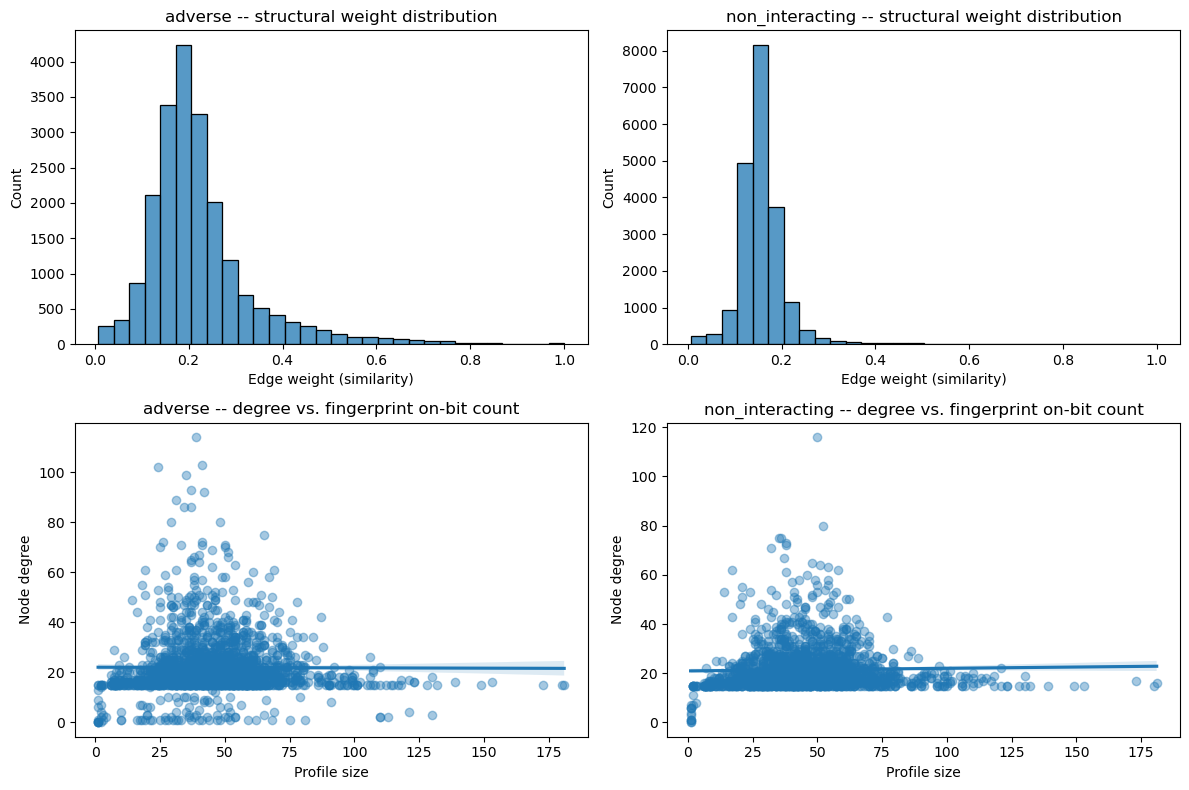

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, label in enumerate(["adverse", "non_interacting"]):
    diag = structural_diag_objects[label]
    diag.plot_weight_distribution(ax=axes[0, col])
    axes[0, col].set_title(f"{label} -- structural weight distribution")
    diag.degree_vs_size(plot=True, ax=axes[1, col])
    axes[1, col].set_title(f"{label} -- degree vs. fingerprint on-bit count")
plt.tight_layout()
plt.show()

## 6. Save graphs

Each graph is written to `networks/{dataset}_structural.graphml`.

In [8]:
for label, G in structural_graphs.items():
    nx.write_graphml(G, OUTPUT_DIR / f"{label}_structural.graphml")

print(f"Saved {len(structural_graphs)} graphs to {OUTPUT_DIR}")

Saved 2 graphs to C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\networks


## 7. Build the combined graph (for node2vec)

`node2vec_embedding.ipynb` needs a **single, label-agnostic** graph to train its canonical embedding on -- using the two per-population graphs above directly would mean two separately-trained node2vec models with unaligned, arbitrary vector spaces (see `node2vec_embedding.ipynb` for why that's invalid for a downstream classifier). Instead, we build one graph from the union of both pair populations here, using the same sparsification settings (`K_NEIGHBORS`, `MIN_SIMILARITY`) as Section 4, so it's saved alongside the other two and node2vec_embedding.ipynb can just load it.

In [9]:
combined_structural_df = pd.concat([adverse_structural_df, non_interacting_structural_df], ignore_index=True)

combined_sim_df = edge_list_to_matrix(combined_structural_df, weight_col="similarity_score")
G_combined = build_sparsified_graph(combined_sim_df, method="hybrid", k=K_NEIGHBORS, min_sim=MIN_SIMILARITY)
nx.set_node_attributes(G_combined, derive_name_lookup(combined_structural_df), "name")

n_isolates = sum(1 for _, deg in G_combined.degree() if deg == 0)
print(f"Combined graph: {G_combined.number_of_nodes():,} nodes, {G_combined.number_of_edges():,} edges, "
      f"{n_isolates} isolate(s), density={nx.density(G_combined):.5f}")

nx.write_graphml(G_combined, OUTPUT_DIR / "combined_structural.graphml")
print(f"Saved to {OUTPUT_DIR / 'combined_structural.graphml'}")

Combined graph: 1,893 nodes, 20,904 edges, 1 isolate(s), density=0.01167
Saved to C:\Users\ashto\ddi-prediction\notebooks\h3_structural_similarity\networks\combined_structural.graphml


In [10]:
adverse_drugs = set(adverse_structural_df["drug1_id"]) | set(adverse_structural_df["drug2_id"])
non_interacting_drugs = set(non_interacting_structural_df["drug1_id"]) | set(non_interacting_structural_df["drug2_id"])
print(f"adverse unique drugs: {len(adverse_drugs)}")
print(f"non_interacting unique drugs: {len(non_interacting_drugs)}")
print(f"in both: {len(adverse_drugs & non_interacting_drugs)}")
print(f"only in adverse: {len(adverse_drugs - non_interacting_drugs)}")
print(f"only in non_interacting: {len(non_interacting_drugs - adverse_drugs)}")
print(f"union: {len(adverse_drugs | non_interacting_drugs)}")


adverse unique drugs: 1893
non_interacting unique drugs: 1893
in both: 1893
only in adverse: 0
only in non_interacting: 0
union: 1893


## Summary & limitations

**How to read `structural_diagnostics_df`:**
- `isolate_count` should be 0 and `n_edges` should scale roughly with `n_nodes * K_NEIGHBORS / 2`.
- `rho_size_diff` / `degree_vs_size_slope` near 0 mean Tanimoto similarity isn't just an artifact of fingerprint on-bit richness; a strong positive slope flags a graph where structurally "busy" molecules dominate connectivity.
- `auroc_ddi_prediction` (adverse row only) above 0.5 means structural similarity helps separate known adverse DDI pairs from random pairs.

**Known limitations:**
1. The dense matrices are built only from the sampled adverse/non-interacting pairs (see the caveat at the top of this notebook) -- not the full drug universe.
2. Fingerprint on-bit count is a proxy for structural complexity, not a direct measure of it -- two molecules with the same on-bit count can be very different in size/shape.
3. `K_NEIGHBORS` / `MIN_SIMILARITY` were chosen to match the other two feature-type notebooks for comparability -- a dedicated grid search (see `run_diagnostic_sweep` in `src/network_builder.py`) may find better settings for this feature type specifically.
4. The combined graph (Section 7) isn't run through the same diagnostics suite as the two per-population graphs -- it's built purely as node2vec training input, not as an object to be evaluated on its own.